In [ ]:
# ============================================================
# Setup & Imports
# ============================================================
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "ee": "earthengine-api",
    "xgboost": "xgboost",
    "rasterio": "rasterio",
    "pyproj": "pyproj",
}

missing_packages = [
    pip_name
    for import_name, pip_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(import_name) is None
]

if missing_packages:
    print(f"Installing missing packages: {missing_packages}")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing_packages])
else:
    print("Required packages are already available")

from google.colab import drive
drive.mount('/content/drive/')

import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, time, json, warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.base import clone

try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print("xgboost is unavailable; XGBoost model will be skipped.")


Required packages are already available
Mounted at /content/drive/


In [ ]:
# ============================================================
# Configuration
# ============================================================
PROJECT_ID = 'gen-lang-client-0366415598'
CSV_FILE   = '/content/drive/MyDrive/vs30data.csv'
CACHE_DIR  = '/content/drive/MyDrive/vs30_cache'
USGS_TIF   = '/content/drive/MyDrive/California_vs30_Wills15_hybrid_7p5c/California_vs30_Wills15_hybrid_7p5c.tif'

RUN_USGS_BASELINE = True
RUN_CONUS_GRID_EXTRACTION = False
FORCE_REBUILD_GRID_PREDICTIONS = False

LAT_COL    = 'Latitude'
LON_COL    = 'Longitude'
TARGET_COL = 'Vs30 (m/s)'

AE_YEAR       = 2024
RANDOM_STATE  = 42
CV_FOLDS      = 3
N_ITER_SEARCH = 10

TECTONIC_BOUNDARY_LON = -105.0

CONUS = {'lat_min': 24.5, 'lat_max': 49.5,
         'lon_min': -125.0, 'lon_max': -66.5}

MAP_RESOLUTION_M = 1000

os.makedirs(CACHE_DIR, exist_ok=True)
print(f"Config: year={AE_YEAR}, CV={CV_FOLDS}-fold, map_res={MAP_RESOLUTION_M}m")
print(f"Cache directory: {CACHE_DIR}")
print(f"USGS baseline enabled: {RUN_USGS_BASELINE}")
print(f"CONUS grid extraction enabled: {RUN_CONUS_GRID_EXTRACTION}")
print(f"Force rebuild grid predictions: {FORCE_REBUILD_GRID_PREDICTIONS}")


Config: year=2024, CV=3-fold, map_res=1000m
Cache directory: /content/drive/MyDrive/vs30_cache
USGS baseline enabled: True
CONUS grid extraction enabled: False
Force rebuild grid predictions: False


In [ ]:
# ============================================================
# Earth Engine Initialization
# ============================================================
try:
    ee.Initialize(project=PROJECT_ID)
    print("Earth Engine initialized")
except Exception:
    print("Authenticating Earth Engine...")
    ee.Authenticate()
    ee.Initialize(project=PROJECT_ID)
    print("Earth Engine authenticated & initialized")


Authenticating Earth Engine...
Earth Engine authenticated & initialized


In [ ]:
# ============================================================
# Load & Clean Station Data
# ============================================================
df_raw = pd.read_csv(CSV_FILE)
df_clean = df_raw[[LAT_COL, LON_COL, TARGET_COL]].dropna()
df_us = df_clean[df_clean[TARGET_COL] > 0].reset_index(drop=True)

# Normalize any mixed/wrapped longitude into [-180, 180].
df_us[LON_COL] = ((df_us[LON_COL].astype(float) + 180.0) % 360.0) - 180.0

df_us['tectonic'] = (df_us[LON_COL] < TECTONIC_BOUNDARY_LON).astype(int)

CA_BBOX = {"lat_min": 32.0, "lat_max": 42.5, "lon_min": -124.6, "lon_max": -114.1}
df_us["is_ca_bbox"] = (
    (df_us[LAT_COL].between(CA_BBOX["lat_min"], CA_BBOX["lat_max"])) &
    (df_us[LON_COL].between(CA_BBOX["lon_min"], CA_BBOX["lon_max"]))
).astype(int)

print(f"samples: {len(df_us)}")
print(f"   Active (west): {df_us['tectonic'].sum()}, Stable (east): {(1-df_us['tectonic']).sum()}")
print(f"   CA(bbox) samples: {int(df_us['is_ca_bbox'].sum())}")


samples: 4386
   Active (west): 3436, Stable (east): 950
   CA(bbox) samples: 1923


In [ ]:
# ============================================================
# Earth Engine Image Loaders
# ============================================================
def load_alphaearth_image(year=2024):
    """Load AlphaEarth 64-dim annual embedding."""
    return (ee.ImageCollection('GOOGLE/SATELLITE_EMBEDDING/V1/ANNUAL')
            .filterDate(f'{year}-01-01', f'{year+1}-01-01')
            .mosaic())

def load_slope_image_30arcsec():
    """Compute slope (m/m) on a 30 arc-second EPSG:4326 grid."""
    dem_1as = ee.Image('USGS/SRTMGL1_003').select('elevation')

    d = 30.0 / 3600.0  # degrees
    crs_transform_30as = [d, 0, -180, 0, -d, 90]

    dem_30as = (dem_1as
        .reduceResolution(reducer=ee.Reducer.mean(), maxPixels=4096)
        .reproject(crs='EPSG:4326', crsTransform=crs_transform_30as)
    )

    slope_deg = ee.Terrain.slope(dem_30as)
    slope_mm = slope_deg.multiply(np.pi / 180.0).tan().rename('slope')
    return slope_mm


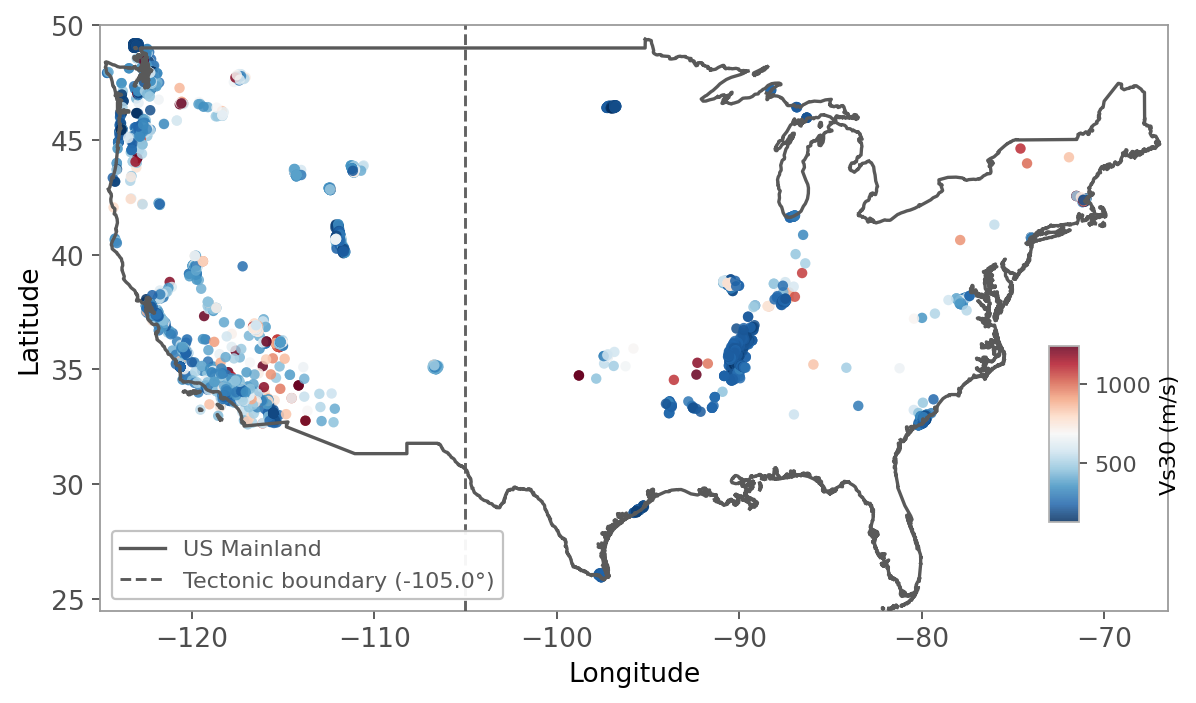

In [ ]:
# ============================================================
# Cell 4b — Ground-Truth Vs30 Map (CONUS style plot)
# ============================================================
from matplotlib.lines import Line2D
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

def _get_conus_outline_info():
    """Get a simplified CONUS outline from EE for plotting."""
    conus_box = ee.Geometry.Rectangle(
        [CONUS['lon_min'], CONUS['lat_min'],
         CONUS['lon_max'], CONUS['lat_max']],
        proj='EPSG:4326',
        geodesic=False
    )

    conus_geom = (
        ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017')
        .filter(ee.Filter.eq('country_co', 'US'))
        .geometry()
        .intersection(conus_box, ee.ErrorMargin(1000))
        .simplify(maxError=2000)
    )
    return conus_geom.getInfo()

def _plot_geojson_outline(ax, geom_info, **kwargs):
    """Plot Polygon / MultiPolygon / GeometryCollection outlines."""
    gtype = geom_info['type']

    if gtype == 'Polygon':
        xy = np.asarray(geom_info['coordinates'][0])   # exterior ring
        ax.plot(xy[:, 0], xy[:, 1], **kwargs)

    elif gtype == 'MultiPolygon':
        for poly in geom_info['coordinates']:
            xy = np.asarray(poly[0])                   # exterior ring
            ax.plot(xy[:, 0], xy[:, 1], **kwargs)

    elif gtype == 'LineString':
        xy = np.asarray(geom_info['coordinates'])
        ax.plot(xy[:, 0], xy[:, 1], **kwargs)

    elif gtype == 'MultiLineString':
        for line in geom_info['coordinates']:
            xy = np.asarray(line)
            ax.plot(xy[:, 0], xy[:, 1], **kwargs)

    elif gtype == 'GeometryCollection':
        for g in geom_info['geometries']:
            _plot_geojson_outline(ax, g, **kwargs)

def plot_groundtruth_vs30_map(df, value_col=TARGET_COL):
    """Plot ground-truth Vs30 station locations/values in a style similar to the example."""
    FONT_SIZE = 12

    df_plot = df.loc[
        df[LAT_COL].between(CONUS['lat_min'], CONUS['lat_max']) &
        df[LON_COL].between(CONUS['lon_min'], CONUS['lon_max']) &
        df[value_col].gt(0)
    ].copy()

    if df_plot.empty:
        raise ValueError("No CONUS ground-truth points available for plotting.")

    outline_info = _get_conus_outline_info()

    # Robust color stretch for a look similar to the example figure
    vmin, vmax = np.nanpercentile(df_plot[value_col], [1, 99])

    fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=160)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    sc = ax.scatter(
        df_plot[LON_COL],
        df_plot[LAT_COL],
        c=df_plot[value_col],
        cmap='RdBu_r',
        vmin=vmin,
        vmax=vmax,
        s=22,
        alpha=0.85,
        linewidths=0,
        zorder=2,
        rasterized=True
    )

    # US mainland outline
    _plot_geojson_outline(ax, outline_info, color='0.35', lw=1.5, zorder=3)

    # Tectonic boundary
    ax.axvline(
        TECTONIC_BOUNDARY_LON,
        color='0.35',
        ls='--',
        lw=1.3,
        alpha=0.95,
        zorder=4,
    )

    ax.set_xlim(CONUS['lon_min'], CONUS['lon_max'])
    ax.set_ylim(CONUS['lat_min'], CONUS['lat_max'])
    ax.set_xticks(np.arange(-120, -69, 10))
    ax.set_yticks(np.arange(25, 51, 5))
    ax.set_xlabel('Longitude', fontsize=FONT_SIZE)
    ax.set_ylabel('Latitude', fontsize=FONT_SIZE)

    for spine in ax.spines.values():
        spine.set_color('0.6')
        spine.set_linewidth(0.8)
    ax.tick_params(colors='0.3', labelsize=FONT_SIZE)

    # Legend: mainland + tectonic dashed line
    legend_handles = [
        Line2D([0], [0], color='0.35', lw=1.5, label='US Mainland'),
        Line2D([0], [0], color='0.35', lw=1.3, ls='--',
               label=f'Tectonic boundary ({TECTONIC_BOUNDARY_LON}°)')
    ]
    leg = ax.legend(
        handles=legend_handles,
        loc='lower left',
        frameon=True,
        facecolor='white',
        edgecolor='0.75',
        framealpha=0.95,
        fontsize=10
    )
    for t in leg.get_texts():
        t.set_color('0.35')

    # Inset vertical colorbar at bottom right
    cax = inset_axes(
        ax,
        width="2.8%",
        height="30%",
        loc='lower right',
        borderpad=4.0
    )
    cbar = plt.colorbar(sc, cax=cax, orientation='vertical')
    cbar.set_label('Vs30 (m/s)', fontsize=10)
    cbar.outline.set_edgecolor('0.7')
    cbar.ax.tick_params(labelsize=10, colors='0.3')

    plt.tight_layout()
    fig.savefig(os.path.join(CACHE_DIR, 'groundtruth_vs30_map.png'),
                dpi=300, bbox_inches='tight', facecolor='white')
    fig.savefig(os.path.join(CACHE_DIR, 'groundtruth_vs30_map.pdf'),
               facecolor='white')
    plt.show()

plot_groundtruth_vs30_map(df_us)


In [ ]:
# ============================================================
# Cell 6 — Feature Extraction with Caching
# ============================================================
def extract_features_batch(df, images_dict, batch_size=500, scale=10):
    """Extract features from stacked GEE images in batches."""
    combined = None
    for name, img in images_dict.items():
        combined = img if combined is None else combined.addBands(img)

    all_results = []
    n_batches = int(np.ceil(len(df) / batch_size))

    for b in range(n_batches):
        start = b * batch_size
        end   = min((b + 1) * batch_size, len(df))
        df_b  = df.iloc[start:end]
        print(f"  🛰️  Batch {b+1}/{n_batches} ({start}-{end-1})...", end='', flush=True)
        t0 = time.time()

        features = []
        for i, row in df_b.iterrows():
            geom = ee.Geometry.Point([row[LON_COL], row[LAT_COL]])
            feat = ee.Feature(geom, {'point_id': int(i),
                                     'target': float(row[TARGET_COL])})
            features.append(feat)
        fc = ee.FeatureCollection(features)

        sampled = combined.sampleRegions(
            collection=fc,
            properties=['point_id', 'target'],
            scale=scale,
            geometries=False
        )
        try:
            raw = sampled.getInfo()
            batch_list = [f['properties'] for f in raw['features']]
            all_results.extend(batch_list)
            print(f" {len(batch_list)} pts ({time.time()-t0:.1f}s)")
        except Exception as e:
            print(f" ⚠️ {e}")
    return pd.DataFrame(all_results)

# ============================================================
# Cell 6 — Feature Extraction with Caching  (only change: use slope-only terrain image)
# ============================================================
def get_cached_features(df, year=2024, cache_dir=CACHE_DIR, scale=100):
    """Load cached or extract & cache AlphaEarth + slope features."""
    cache_file = os.path.join(cache_dir,
                              f'ae_slope_y{year}_s{scale}_n{len(df)}.csv')
    if os.path.exists(cache_file):
        print(f"📁 Loading cache: {cache_file}")
        feat_df = pd.read_csv(cache_file)
        print(f"   {feat_df.shape[0]} rows × {feat_df.shape[1]} cols")
        return feat_df

    print(f"🛰️  Extracting AlphaEarth {year} + slope for {len(df)} pts (scale={scale}m)...")
    emb_img = load_alphaearth_image(year)
    slope_img = load_slope_image_30arcsec()

    feat_df = extract_features_batch(df, {'ae': emb_img, 'terrain': slope_img},
                                     batch_size=500, scale=scale)
    feat_df.to_csv(cache_file, index=False)
    print(f"💾 Cached → {cache_file}")
    return feat_df


In [ ]:
# ============================================================
# Cell 7 — Extract & Merge Features  (REMOVE elevation, KEEP tectonic, KEEP log_slope)
# ============================================================
feat_df = get_cached_features(df_us, year=AE_YEAR, scale=1000)

band_cols = sorted([c for c in feat_df.columns
                    if c.startswith('A') and c[1:].isdigit()],
                   key=lambda x: int(x[1:]))

if "slope" not in feat_df.columns:
    raise ValueError("Missing slope in feature table. Ensure terrain image includes slope band.")

terrain_cols = ["slope"]

print(f"🔢 Embedding bands: {len(band_cols)}  ({band_cols[0]}..{band_cols[-1]})")
print(f"🏔️  Terrain features: {terrain_cols}")

feat_df['point_id'] = feat_df['point_id'].astype(int)
df_m = df_us.copy()
df_m['point_id'] = df_m.index
df_m = df_m.merge(feat_df[['point_id'] + band_cols + terrain_cols],
                  on='point_id', how='inner')

# --- Compute log10 of slope ---
df_m['log_slope'] = np.log10(df_m['slope'].clip(lower=1e-8))
log_terrain_cols = ['log_slope']

print(f"🔢 AE bands: {len(band_cols)}  ({band_cols[0]}..{band_cols[-1]})")
print(f"🏔️  Log terrain: {log_terrain_cols}")

all_feat_cols = band_cols + log_terrain_cols + ['tectonic']
df_m = df_m.dropna(subset=all_feat_cols + [TARGET_COL]).reset_index(drop=True)

print(f"\n✅ Dataset: {len(df_m)} samples")
print(f"   AlphaEarth: {len(band_cols)} bands (raw)")
print(f"   Log Terrain:    {len(log_terrain_cols)} features")
print(f"   Tectonic:       1 binary feature")
print(f"   CA(bbox) usable samples: {int(df_m['is_ca_bbox'].sum())}")


📁 Loading cache: /content/drive/MyDrive/vs30_cache/ae_slope_y2024_s1000_n4386.csv
   2886 rows × 67 cols
🔢 Embedding bands: 64  (A00..A63)
🏔️  Terrain features: ['slope']
🔢 AE bands: 64  (A00..A63)
🏔️  Log terrain: ['log_slope']

✅ Dataset: 2886 samples
   AlphaEarth: 64 bands (raw)
   Log Terrain:    1 features
   Tectonic:       1 binary feature
   CA(bbox) usable samples: 1071


In [ ]:
# ============================================================
# Cell 8 — Define Feature Sets  (KEEP tectonic feature; elevation removed already)
# ============================================================
FEATURE_SETS = {
    'AE_only':                  band_cols,
    'log_slope+tectonic':       ['log_slope', 'tectonic'],
    'AE+log_slope':             band_cols + ['log_slope'],
    'AE+log_slope+tectonic':    band_cols + ['log_slope', 'tectonic'],
}

print("📋 Feature sets:")
for name, cols in FEATURE_SETS.items():
    print(f"   {name:25s} → {len(cols)} features")


📋 Feature sets:
   AE_only                   → 64 features
   log_slope+tectonic        → 2 features
   AE+log_slope              → 65 features
   AE+log_slope+tectonic     → 66 features


In [ ]:
# ============================================================
# Cell 9 — Model Configs (LinearReg, RF, XGBoost)
# ============================================================
def get_model_configs():
    configs = {}

    configs['LinearReg'] = (
        LinearRegression(n_jobs=-1),
        {})

    configs['RF'] = (
        RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        {'n_estimators': [200, 400], 'max_depth': [None, 25, 50],
         'max_features': ['sqrt', 0.3], 'min_samples_leaf': [1, 5]})

    if HAS_XGB:
        configs['XGBoost'] = (
            XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1,
                         verbosity=0, tree_method='hist'),
            {'n_estimators': [200, 400], 'learning_rate': [0.05, 0.1],
             'max_depth': [4, 6, 8], 'subsample': [0.7, 0.9],
             'colsample_bytree': [0.6, 0.8], 'reg_lambda': [1, 5]})

    return configs

cv = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
print(f"🤖 Models: {list(get_model_configs().keys())}")
print(f"   CV={CV_FOLDS}-fold, max {N_ITER_SEARCH} iterations per model")


🤖 Models: ['LinearReg', 'RF', 'XGBoost']
   CV=3-fold, max 10 iterations per model


In [ ]:
# ============================================================
# Cell 10 — Run Full Model Selection + repeated-seed CV for HPO
#   ** Target = log10(Vs30) **
#   ** StandardScaler on features **
#   ** Metrics reported in REAL Vs30 space **
#   ** RF/XGBoost HPO averaged over 10 random seeds **
# ============================================================
from sklearn.base import clone
from sklearn.model_selection import ParameterSampler

N_SEED_REPEATS = 5   # change to 50+ later if runtime allows
BASE_SEED = RANDOM_STATE

def set_model_seed(estimator, seed):
    """Set estimator random seed if supported."""
    params = estimator.get_params(deep=False)
    updates = {}
    if 'random_state' in params:
        updates['random_state'] = seed
    if 'seed' in params:
        updates['seed'] = seed
    if updates:
        estimator.set_params(**updates)
    return estimator

def evaluate_config_cv(estimator, params, X_train, y_train_log, seeds, n_splits=CV_FOLDS):
    """
    Evaluate one hyperparameter configuration by averaging CV RMSE(log10 Vs30)
    across multiple random seeds.
    Each seed controls:
      1) shuffled KFold split
      2) estimator randomness (RF/XGBoost)
    """
    cv_rmse_list = []

    for seed in seeds:
        est = clone(estimator)
        if params:
            est.set_params(**params)
        est = set_model_seed(est, seed)

        cv_local = KFold(n_splits=n_splits, shuffle=True, random_state=seed)

        fold_rmses = []
        for tr_idx, va_idx in cv_local.split(X_train):
            X_tr, X_va = X_train[tr_idx], X_train[va_idx]
            y_tr, y_va = y_train_log[tr_idx], y_train_log[va_idx]

            est_fold = clone(est)
            est_fold.fit(X_tr, y_tr)
            y_va_pred = est_fold.predict(X_va)

            rmse_log = np.sqrt(mean_squared_error(y_va, y_va_pred))
            fold_rmses.append(rmse_log)

        cv_rmse_list.append(np.mean(fold_rmses))

    return float(np.mean(cv_rmse_list)), float(np.std(cv_rmse_list))

train_idx, test_idx = train_test_split(
    np.arange(len(df_m)), test_size=0.2, random_state=RANDOM_STATE
)

# Log-transform target
y_train_log = np.log10(df_m.iloc[train_idx][TARGET_COL].values)
y_test_log  = np.log10(df_m.iloc[test_idx][TARGET_COL].values)
y_test_real = df_m.iloc[test_idx][TARGET_COL].values

all_results = []
best_models = {}
scalers = {}
best_params_map = {}
model_configs = get_model_configs()

seed_list = [BASE_SEED + i for i in range(N_SEED_REPEATS)]

for fs_name, fs_cols in FEATURE_SETS.items():
    X_train_raw = df_m.iloc[train_idx][fs_cols].values
    X_test_raw  = df_m.iloc[test_idx][fs_cols].values

    # StandardScaler
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test  = scaler.transform(X_test_raw)
    scalers[fs_name] = scaler

    print(f"\n{'='*65}")
    print(f"🔬 {fs_name}  ({len(fs_cols)} features)  [StandardScaler, log10 target]")
    print(f"{'='*65}")

    for m_name, (base_estimator, param_dist) in model_configs.items():
        print(f"  ▸ {m_name:12s}", end='', flush=True)
        t0 = time.time()

        try:
            # --------------------------------------------------------
            # 1) Hyperparameter selection
            # --------------------------------------------------------
            if not param_dist:
                # LinearRegression: deterministic, no HPO repeats needed
                best_params = {}
                cv_rmse_log, cv_rmse_log_std = evaluate_config_cv(
                    base_estimator,
                    best_params,
                    X_train,
                    y_train_log,
                    seeds=[BASE_SEED],
                    n_splits=CV_FOLDS
                )
            else:
                # sample up to N_ITER_SEARCH combinations once
                max_possible = int(np.prod([len(v) for v in param_dist.values()]))
                n_iter_eff = min(N_ITER_SEARCH, max_possible)

                sampled_params = list(ParameterSampler(
                    param_dist,
                    n_iter=n_iter_eff,
                    random_state=BASE_SEED
                ))

                best_params = None
                cv_rmse_log = np.inf
                cv_rmse_log_std = np.nan

                for params in sampled_params:
                    mean_rmse, std_rmse = evaluate_config_cv(
                        base_estimator,
                        params,
                        X_train,
                        y_train_log,
                        seeds=seed_list,
                        n_splits=CV_FOLDS
                    )

                    if mean_rmse < cv_rmse_log:
                        cv_rmse_log = mean_rmse
                        cv_rmse_log_std = std_rmse
                        best_params = params

            # --------------------------------------------------------
            # 2) Refit best model once on full training set
            # --------------------------------------------------------
            best_est = clone(base_estimator)
            if best_params:
                best_est.set_params(**best_params)
            best_est = set_model_seed(best_est, BASE_SEED)
            best_est.fit(X_train, y_train_log)

            # Predict in log space, convert back for real-space metrics
            y_pred_log = best_est.predict(X_test)
            y_pred_real = 10 ** y_pred_log

            test_rmse = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
            test_mae  = mean_absolute_error(y_test_real, y_pred_real)
            test_r2   = r2_score(y_test_real, y_pred_real)

            # Log-residual stats
            log_res = y_pred_log - y_test_log
            log_mean = float(np.mean(log_res))
            log_std  = float(np.std(log_res))

            # R² in log space
            test_r2_log = r2_score(y_test_log, y_pred_log)

            dt = time.time() - t0

            print(
                f"  CV_log={cv_rmse_log:.4f}±{cv_rmse_log_std:.4f}  "
                f"RMSE={test_rmse:7.1f}  R²={test_r2:.4f}  "
                f"R²_log={test_r2_log:.4f}  logσ={log_std:.3f}  ({dt:.0f}s)"
            )

            all_results.append({
                'feature_set': fs_name,
                'model': m_name,
                'n_features': len(fs_cols),

                'cv_rmse_log': cv_rmse_log,
                'cv_rmse_log_std': cv_rmse_log_std,

                'test_rmse': test_rmse,
                'test_mae': test_mae,
                'test_r2': test_r2,
                'test_r2_log': test_r2_log,
                'log_mean': log_mean,
                'log_std': log_std,

                'n_seed_repeats': 1 if not param_dist else N_SEED_REPEATS,
                'best_params': str(best_params) if best_params else 'default',
                'best_params_dict': best_params if best_params else {},
                'time_s': dt
            })

            best_models[(fs_name, m_name)] = best_est
            best_params_map[(fs_name, m_name)] = best_params if best_params else {}

        except Exception as e:
            print(f"  ❌ {e}")
            all_results.append({
                'feature_set': fs_name,
                'model': m_name,
                'n_features': len(fs_cols),

                'cv_rmse_log': np.nan,
                'cv_rmse_log_std': np.nan,

                'test_rmse': np.nan,
                'test_mae': np.nan,
                'test_r2': np.nan,
                'test_r2_log': np.nan,
                'log_mean': np.nan,
                'log_std': np.nan,

                'n_seed_repeats': 0,
                'best_params': str(e),
                'best_params_dict': {},
                'time_s': time.time() - t0
            })

results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(CACHE_DIR, 'model_selection_results_log.csv'), index=False)

print(f"\n💾 Results saved")



🔬 AE_only  (64 features)  [StandardScaler, log10 target]
  ▸ LinearReg     CV_log=0.1403±0.0000  RMSE=  151.6  R²=0.3248  R²_log=0.4341  logσ=0.144  (0s)
  ▸ RF            CV_log=0.1214±0.0004  RMSE=  131.0  R²=0.4962  R²_log=0.6328  logσ=0.116  (760s)
  ▸ XGBoost       CV_log=0.1205±0.0006  RMSE=  131.5  R²=0.4922  R²_log=0.6309  logσ=0.117  (340s)

🔬 log_slope+tectonic  (2 features)  [StandardScaler, log10 target]
  ▸ LinearReg     CV_log=0.1578±0.0000  RMSE=  166.6  R²=0.1850  R²_log=0.2692  logσ=0.164  (0s)
  ▸ RF            CV_log=0.1555±0.0007  RMSE=  159.0  R²=0.2576  R²_log=0.3440  logσ=0.155  (179s)
  ▸ XGBoost       CV_log=0.1541±0.0006  RMSE=  161.8  R²=0.2314  R²_log=0.3394  logσ=0.156  (17s)

🔬 AE+log_slope  (65 features)  [StandardScaler, log10 target]
  ▸ LinearReg     CV_log=0.1384±0.0000  RMSE=  150.3  R²=0.3367  R²_log=0.4404  logσ=0.144  (0s)
  ▸ RF            CV_log=0.1193±0.0006  RMSE=  127.3  R²=0.5239  R²_log=0.6515  logσ=0.113  (749s)
  ▸ XGBoost       CV_log=0

In [ ]:
# ============================================================
# Results Summary (WHOLE US + CA-only TEST on the SAME test_idx)
# ============================================================
def _get_estimator_params_for_print(est):
    """
    Return a compact dict of hyperparameters for printing.
    Works for plain estimators and simple pipelines.
    """
    if est is None:
        return {}

    if hasattr(est, "named_steps") and len(est.named_steps) > 0:
        final_est = list(est.named_steps.values())[-1]
    else:
        final_est = est

    params = final_est.get_params()

    if final_est.__class__.__name__ in ["RandomForestRegressor", "RandomForestClassifier"]:
        keep = [
            "n_estimators",
            "max_depth",
            "max_features",
            "min_samples_leaf",
            "min_samples_split",
            "random_state",
        ]
    elif final_est.__class__.__name__ in ["XGBRegressor", "XGBClassifier"]:
        keep = [
            "n_estimators",
            "learning_rate",
            "max_depth",
            "subsample",
            "colsample_bytree",
            "reg_lambda",
            "random_state",
        ]
    elif final_est.__class__.__name__ in ["LinearRegression", "Ridge", "Lasso", "ElasticNet"]:
        keep = ["fit_intercept", "positive"]
    else:
        keep = [k for k in params.keys() if "__" not in k]

    return {k: params[k] for k in keep if k in params}

print("\n" + "="*95)
print("RESULTS SUMMARY (sorted by test RMSE, then test R2)")
print("="*95)

cols = ['feature_set', 'model', 'n_features',
        'cv_rmse_log', 'test_rmse', 'test_mae', 'test_r2', 'test_r2_log',
        'log_mean', 'log_std']

summary = results_df[cols].sort_values(['test_rmse', 'test_r2'], ascending=[True, False])
s = summary.copy()
for c in ['cv_rmse_log']:
    s[c] = s[c].map(lambda v: f"{v:.4f}" if pd.notna(v) else "nan")
for c in ['test_rmse', 'test_mae']:
    s[c] = s[c].map(lambda v: f"{v:.1f}" if pd.notna(v) else "nan")
for c in ['test_r2', 'test_r2_log']:
    s[c] = s[c].map(lambda v: f"{v:.4f}" if pd.notna(v) else "nan")
for c in ['log_mean', 'log_std']:
    s[c] = s[c].map(lambda v: f"{v:.3f}" if pd.notna(v) else "nan")
print(s.to_string(index=False))

summary_csv_path = os.path.join(CACHE_DIR, "results_summary_whole_us.csv")
summary.to_csv(summary_csv_path, index=False)
print(f"\nSaved whole-US summary to: {summary_csv_path}")

best_row = results_df.loc[results_df['test_rmse'].idxmin()]
best_fs_name = str(best_row['feature_set'])
best_model_name = str(best_row['model'])

print(f"\nBEST (by test RMSE): {best_model_name} + {best_fs_name}  "
      f"-> RMSE={best_row['test_rmse']:.1f}, MAE={best_row['test_mae']:.1f}, "
      f"R2={best_row['test_r2']:.4f}, logR2={best_row['test_r2_log']:.4f}, "
      f"log_sigma={best_row['log_std']:.3f}")

best_est = best_models.get((best_fs_name, best_model_name))
best_params = _get_estimator_params_for_print(best_est)

print("\nBest model hyperparameters:")
if len(best_params) == 0:
    print("   [No parameters found]")
else:
    for k, v in best_params.items():
        print(f"   {k}: {v}")

print("\nBest model per feature set (by test RMSE):")
for fs in FEATURE_SETS:
    sub = results_df[results_df['feature_set'] == fs].dropna(subset=['test_rmse'])
    if len(sub) == 0:
        continue
    b = sub.loc[sub['test_rmse'].idxmin()]
    print(f"  {fs:25s} -> {b['model']:12s}  RMSE={b['test_rmse']:.1f}  "
          f"R2={b['test_r2']:.4f}  logR2={b['test_r2_log']:.4f}")

# CA-only TEST using BEST whole-US model, restricted to the same test_idx.
best_est = best_models.get((best_fs_name, best_model_name))
best_scaler = scalers.get(best_fs_name)
best_cols = FEATURE_SETS[best_fs_name]
ca_metrics_df = pd.DataFrame()

if best_est is None or best_scaler is None:
    print("\nCould not find best estimator/scaler to run CA-only test.")
else:
    ca_mask_all = df_m["is_ca_bbox"].astype(bool).values

    test_mask_all = np.zeros(len(df_m), dtype=bool)
    test_mask_all[test_idx] = True

    ca_test_mask = ca_mask_all & test_mask_all
    n_ca_test = int(ca_test_mask.sum())

    if n_ca_test == 0:
        print("\nNo CA(bbox) samples in the test set; skipping CA-only test.")
    else:
        X_ca_raw = df_m.loc[ca_test_mask, best_cols].values
        y_ca_real = df_m.loc[ca_test_mask, TARGET_COL].values
        y_ca_log  = np.log10(y_ca_real)

        X_ca = best_scaler.transform(X_ca_raw)
        yhat_ca_log  = best_est.predict(X_ca)
        yhat_ca_real = 10**yhat_ca_log

        ca_rmse = float(np.sqrt(mean_squared_error(y_ca_real, yhat_ca_real)))
        ca_mae  = float(mean_absolute_error(y_ca_real, yhat_ca_real))
        ca_r2   = float(r2_score(y_ca_real, yhat_ca_real))
        ca_r2l  = float(r2_score(y_ca_log, yhat_ca_log))
        ca_log_res = yhat_ca_log - y_ca_log
        ca_log_mean = float(np.mean(ca_log_res))
        ca_log_std = float(np.std(ca_log_res))

        ca_metrics_df = pd.DataFrame([{
            "model": best_model_name,
            "feature_set": best_fs_name,
            "n_test_ca_valid": n_ca_test,
            "test_rmse": ca_rmse,
            "test_mae": ca_mae,
            "test_r2": ca_r2,
            "test_r2_log": ca_r2l,
            "log_mean": ca_log_mean,
            "log_std": ca_log_std,
        }])

        print("\n" + "-"*95)
        print("CA-only TEST (restricted to SAME test_idx) using BEST whole-US model")
        print(f"   Model: {best_model_name}   Feature set: {best_fs_name}   N(CA_test)={n_ca_test}")
        print(f"   RMSE={ca_rmse:.1f}  MAE={ca_mae:.1f}  R2={ca_r2:.4f}  logR2={ca_r2l:.4f}  log_sigma={ca_log_std:.3f}")
        print("-"*95)
        display(ca_metrics_df)



RESULTS SUMMARY (sorted by test RMSE, then test R2)
          feature_set     model  n_features cv_rmse_log test_rmse test_mae test_r2 test_r2_log log_mean log_std
         AE+log_slope   XGBoost          65      0.1185     126.1     66.2  0.5329      0.6525    0.002   0.113
         AE+log_slope        RF          65      0.1193     127.3     66.1  0.5239      0.6515    0.003   0.113
AE+log_slope+tectonic        RF          66      0.1191     127.4     66.0  0.5231      0.6513    0.003   0.113
AE+log_slope+tectonic   XGBoost          66      0.1182     128.8     66.8  0.5131      0.6433    0.002   0.115
              AE_only        RF          64      0.1214     131.0     67.0  0.4962      0.6328    0.002   0.116
              AE_only   XGBoost          64      0.1205     131.5     67.5  0.4922      0.6309   -0.000   0.117
AE+log_slope+tectonic LinearReg          66      0.1383     150.1     87.9  0.3384      0.4410    0.004   0.143
         AE+log_slope LinearReg          65      0.

,model,feature_set,n_test_ca_valid,test_rmse,test_mae,test_r2,test_r2_log,log_mean,log_std
0,XGBoost,AE+log_slope,211,129.997775,73.201512,0.586422,0.688666,-0.008544,0.103734


In [ ]:
# ============================================================
# Optional USGS baseline raster vs measurements
# ============================================================
import rasterio
from pyproj import Transformer

usgs_baseline_df = pd.DataFrame()

if not RUN_USGS_BASELINE:
    print("Skipping USGS baseline comparison because RUN_USGS_BASELINE=False.")
elif not os.path.exists(USGS_TIF):
    print(f"Skipping USGS baseline comparison because the raster was not found: {USGS_TIF}")
else:
    ca_mask_all = df_m["is_ca_bbox"].astype(bool).values

    test_mask_all = np.zeros(len(df_m), dtype=bool)
    test_mask_all[test_idx] = True

    ca_test_mask = ca_mask_all & test_mask_all
    n_ca_test = int(ca_test_mask.sum())

    if n_ca_test == 0:
        print("No CA(bbox) samples in the test set; skipping USGS comparison.")
    else:
        df_ca_test = df_m.loc[ca_test_mask].copy()

        lon = df_ca_test[LON_COL].values.astype(float)
        lat = df_ca_test[LAT_COL].values.astype(float)
        y_true_real = df_ca_test[TARGET_COL].values.astype(float)
        y_true_log = np.log10(y_true_real)

        with rasterio.open(USGS_TIF) as src:
            print("Raster CRS:", src.crs)
            print("Raster nodata:", src.nodata)
            print("Raster bounds:", src.bounds)

            if src.crs is not None and str(src.crs).lower() not in ["epsg:4326", "ogc:crs84"]:
                transformer = Transformer.from_crs("EPSG:4326", src.crs, always_xy=True)
                x, y = transformer.transform(lon, lat)
                coords = list(zip(x, y))
            else:
                coords = list(zip(lon, lat))

            sampled = np.array([v[0] for v in src.sample(coords)], dtype=float)

            if src.nodata is not None:
                valid_mask = np.isfinite(sampled) & (sampled != src.nodata)
            else:
                valid_mask = np.isfinite(sampled)

        y_usgs_real = sampled[valid_mask]
        y_meas_real = y_true_real[valid_mask]

        if len(y_usgs_real) == 0:
            print("No valid USGS raster samples found at CA test points.")
        else:
            positive_mask = (y_usgs_real > 0) & (y_meas_real > 0)
            y_usgs_real = y_usgs_real[positive_mask]
            y_meas_real = y_meas_real[positive_mask]

            y_usgs_log = np.log10(y_usgs_real)
            y_meas_log = np.log10(y_meas_real)

            usgs_rmse = float(np.sqrt(mean_squared_error(y_meas_real, y_usgs_real)))
            usgs_mae  = float(mean_absolute_error(y_meas_real, y_usgs_real))
            usgs_r2   = float(r2_score(y_meas_real, y_usgs_real))
            usgs_r2l  = float(r2_score(y_meas_log, y_usgs_log))

            usgs_log_res = y_usgs_log - y_meas_log
            usgs_log_mean = float(np.mean(usgs_log_res))
            usgs_log_std  = float(np.std(usgs_log_res))

            print("\n" + "-"*95)
            print("USGS BASELINE TEST (restricted to SAME CA test_idx subset)")
            print(f"   Raster: {USGS_TIF}")
            print(f"   N(valid CA_test)={len(y_usgs_real)} / {n_ca_test}")
            print(f"   RMSE={usgs_rmse:.1f}  MAE={usgs_mae:.1f}  "
                  f"R2={usgs_r2:.4f}  logR2={usgs_r2l:.4f}  "
                  f"log_mean={usgs_log_mean:.3f}  log_sigma={usgs_log_std:.3f}")
            print("-"*95)

            usgs_baseline_metrics = {
                "model": "USGS_Wills15_hybrid_7p5c",
                "feature_set": "external_baseline",
                "n_test_ca_valid": len(y_usgs_real),
                "test_rmse": usgs_rmse,
                "test_mae": usgs_mae,
                "test_r2": usgs_r2,
                "test_r2_log": usgs_r2l,
                "log_mean": usgs_log_mean,
                "log_std": usgs_log_std,
            }

            usgs_baseline_df = pd.DataFrame([usgs_baseline_metrics])
            display(usgs_baseline_df)

            if len(ca_metrics_df) > 0:
                ml_vs_usgs_df = pd.concat(
                    [ca_metrics_df.copy(), usgs_baseline_df.copy()],
                    ignore_index=True,
                    sort=False
                )
                compare_csv_path = os.path.join(CACHE_DIR, "ca_test_ml_vs_usgs_comparison.csv")
                ml_vs_usgs_df.to_csv(compare_csv_path, index=False)
                print(f"Saved CA test ML-vs-USGS comparison to: {compare_csv_path}")
                display(ml_vs_usgs_df)


Raster CRS: EPSG:4326
Raster nodata: -3.3999999521443642e+38
Raster bounds: BoundingBox(left=-124.501041667, bottom=32.498958335, right=-114.098958335, top=42.101041667)

-----------------------------------------------------------------------------------------------
USGS BASELINE TEST (restricted to SAME CA test_idx subset)
   Raster: /content/drive/MyDrive/California_vs30_Wills15_hybrid_7p5c/California_vs30_Wills15_hybrid_7p5c.tif
   N(valid CA_test)=167 / 211
   RMSE=129.8  MAE=87.8  R2=0.3983  logR2=0.3623  log_mean=-0.004  log_sigma=0.135
-----------------------------------------------------------------------------------------------


,model,feature_set,n_test_ca_valid,test_rmse,test_mae,test_r2,test_r2_log,log_mean,log_std
0,USGS_Wills15_hybrid_7p5c,external_baseline,167,129.756247,87.785934,0.398301,0.36227,-0.004333,0.135483


Saved CA test ML-vs-USGS comparison to: /content/drive/MyDrive/vs30_cache/ca_test_ml_vs_usgs_comparison.csv


,model,feature_set,n_test_ca_valid,test_rmse,test_mae,test_r2,test_r2_log,log_mean,log_std
0,XGBoost,AE+log_slope,211,129.997775,73.201512,0.586422,0.688666,-0.008544,0.103734
1,USGS_Wills15_hybrid_7p5c,external_baseline,167,129.756247,87.785934,0.398301,0.362270,-0.004333,0.135483


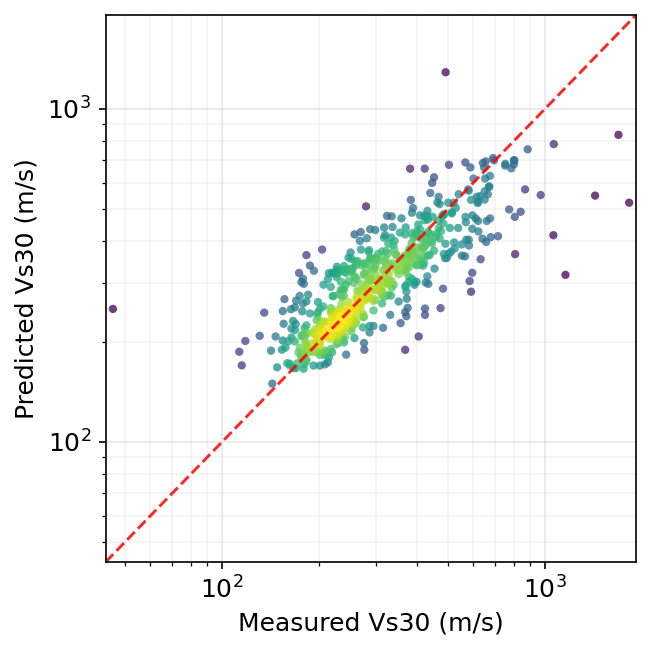

In [ ]:
# ============================================================
# Pred vs Actual for Best Model
# Similar color style to the reference figure
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
from matplotlib.ticker import LogLocator, LogFormatterMathtext
from scipy.stats import gaussian_kde

plt.rcParams.update({'font.size': 12})

best_key = (best_row['feature_set'], best_row['model'])
best_est = best_models.get(best_key)
best_fs_cols = FEATURE_SETS[best_row['feature_set']]
fs_name = best_row['feature_set']

if best_est is None:
    raise ValueError(f"No model found for best_key={best_key}")

X_test_raw = df_m.iloc[test_idx][best_fs_cols].values
X_test_sc  = scalers[fs_name].transform(X_test_raw)
y_pred_log = best_est.predict(X_test_sc)

# convert log10 -> linear Vs30 (m/s)
y_true = 10 ** y_test_log
y_pred = 10 ** y_pred_log

# ------------------------------------------------------------
# Density coloring in log10 space for log-log scatter
# ------------------------------------------------------------
xy_log = np.vstack([np.log10(y_true), np.log10(y_pred)])
z = gaussian_kde(xy_log, bw_method='scott')(xy_log)

# plot low-density points first, high-density points last
order = np.argsort(z)
x_plot = y_true[order]
y_plot = y_pred[order]
z_plot = z[order]

# axis limits in linear space
mn = min(y_true.min(), y_pred.min())
mx = max(y_true.max(), y_pred.max())
lims = (mn * 0.95, mx * 1.05)

fig, ax = plt.subplots(figsize=(4.5, 4.5), dpi=150)

# white/default background, no panel fill
norm = PowerNorm(
    gamma=0.45,
    vmin=np.percentile(z_plot, 1),
    vmax=np.percentile(z_plot, 99.7),
    clip=True
)

ax.scatter(
    x_plot,
    y_plot,
    c=z_plot,
    cmap='viridis',   # purple -> green -> yellow
    norm=norm,
    s=16,
    alpha=0.75,
    edgecolors='none',
    rasterized=True
)

# 1:1 line
ax.plot(lims, lims, '--', color='red', lw=1.4, alpha=0.85)

# log-log axes with 10^x tick formatting
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(lims)
ax.set_ylim(lims)

ax.xaxis.set_major_locator(LogLocator(base=10))
ax.yaxis.set_major_locator(LogLocator(base=10))
ax.xaxis.set_major_formatter(LogFormatterMathtext(base=10))
ax.yaxis.set_major_formatter(LogFormatterMathtext(base=10))

ax.set_xlabel('Measured Vs30 (m/s)')
ax.set_ylabel('Predicted Vs30 (m/s)')

# keep grid
ax.grid(True, which='major', alpha=0.3)
ax.grid(True, which='minor', alpha=0.15)
ax.set_axisbelow(True)

plt.tight_layout()
fig.savefig(os.path.join(CACHE_DIR, 'best_pred_vs_actual_logaxis.png'),
            dpi=150, bbox_inches='tight')
fig.savefig(os.path.join(CACHE_DIR, 'best_pred_vs_actual_logaxis.pdf'),
            bbox_inches='tight')
plt.show()


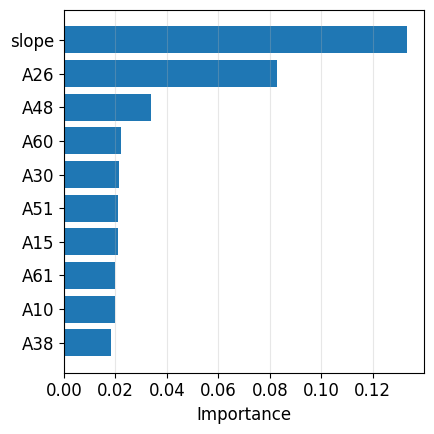

In [ ]:
plt.rcParams.update({'font.size': 12})

best_key = (best_row['feature_set'], best_row['model'])
best_est = best_models.get(best_key)
best_fs_cols = FEATURE_SETS[best_row['feature_set']]

imp = None
if hasattr(best_est, 'feature_importances_'):
    imp = best_est.feature_importances_
elif hasattr(best_est, 'named_steps'):
    for _, step in best_est.named_steps.items():
        if hasattr(step, 'feature_importances_'):
            imp = step.feature_importances_
            break

if imp is None:
    print("Best estimator does not provide feature_importances_.")
else:
    n_top = min(10, len(imp))
    idx = np.argsort(imp)[-n_top:]  # ascending; largest ends up at top of plot

    # labels + requested renames
    rename_map = {"log_slope": "slope", "tectonic": "status"}
    labels = [rename_map.get(best_fs_cols[i], best_fs_cols[i]) for i in idx]

    fig, ax = plt.subplots(figsize=(4.5, 4.5))
    ax.barh(range(n_top), imp[idx])
    ax.set_yticks(range(n_top))
    ax.set_yticklabels(labels)

    ax.set_xlabel('Importance')
    ax.grid(True, axis='x', alpha=0.3)

    plt.tight_layout()
    fig.savefig(os.path.join(CACHE_DIR, 'best_feature_importance.png'),
                dpi=150, bbox_inches='tight')
    fig.savefig(os.path.join(CACHE_DIR, 'best_feature_importance.pdf'),
                bbox_inches='tight')
    plt.show()


In [ ]:
# ============================================================
# Final Model Retraining on ALL Data (log10 target)
# ============================================================
FINAL_FEATURE_SET = str(best_row['feature_set'])
FINAL_MODEL_NAME = str(best_row['model'])
FINAL_FEATURE_COLS = FEATURE_SETS[FINAL_FEATURE_SET]

base_final_est = best_models.get((FINAL_FEATURE_SET, FINAL_MODEL_NAME))
if base_final_est is None:
    raise ValueError(f"No fitted estimator found for {(FINAL_FEATURE_SET, FINAL_MODEL_NAME)}")

print(f"Retraining: {FINAL_MODEL_NAME} + {FINAL_FEATURE_SET} on ALL data...")

final_model = clone(base_final_est)
final_model = set_model_seed(final_model, RANDOM_STATE)

X_all_raw = df_m[FINAL_FEATURE_COLS].values
y_all_log = np.log10(df_m[TARGET_COL].values)

final_scaler = StandardScaler()
X_all = final_scaler.fit_transform(X_all_raw)
final_model.fit(X_all, y_all_log)

USE_TECTONIC = 'tectonic' in FINAL_FEATURE_COLS
USE_SLOPE = any(c in FINAL_FEATURE_COLS for c in ['slope', 'log_slope', 'elevation'])

print(f"Final model trained on {len(y_all_log)} samples (log10 target)")
print(f"   Features: {FINAL_FEATURE_SET} ({len(FINAL_FEATURE_COLS)})")
print(f"   tectonic={USE_TECTONIC}, slope={USE_SLOPE}")


Retraining: XGBoost + AE+log_slope on ALL data...
Final model trained on 2886 samples (log10 target)
   Features: AE+log_slope (65)
   tectonic=False, slope=True


In [ ]:
# ============================================================
# CONUS Land Grid + Feature Cache Helpers
# ============================================================
import os
import glob
import numpy as np
import pandas as pd

GRID_SPACING_KM = 1
FEATURE_BATCH_SIZE = 1000   # safer than 5000 for EE
GRID_CACHE_TAG = "v3_conus_lon180_slopeonly"
GRID_COORD_DECIMALS = 6


def wrap_lon_to_180(lon):
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180.0) % 360.0) - 180.0

def normalize_grid_coords(df):
    out = df.copy()

    if LAT_COL in out.columns:
        out[LAT_COL] = pd.to_numeric(out[LAT_COL], errors='coerce').astype(float).round(GRID_COORD_DECIMALS)

    if LON_COL in out.columns:
        out[LON_COL] = wrap_lon_to_180(
            pd.to_numeric(out[LON_COL], errors='coerce').astype(float)
        ).round(GRID_COORD_DECIMALS)

    if 'point_id' in out.columns:
        out['point_id'] = pd.to_numeric(out['point_id'], errors='raise').astype(int)
        out = (
            out.sort_values('point_id')
               .drop_duplicates(subset='point_id', keep='last')
               .reset_index(drop=True)
        )
    else:
        out = out.reset_index(drop=True)

    return out

def summarize_grid(df, name):
    print(
        f"{name}: {len(df)} rows | "
        f"lat [{df[LAT_COL].min():.3f}, {df[LAT_COL].max():.3f}] | "
        f"lon [{df[LON_COL].min():.3f}, {df[LON_COL].max():.3f}]"
    )
    if (~df[LON_COL].between(-180, 180)).any():
        bad_n = (~df[LON_COL].between(-180, 180)).sum()
        raise ValueError(f"{name}: {bad_n} longitude value(s) still outside [-180, 180].")

def get_us_boundary():
    return (
        ee.FeatureCollection('USDOS/LSIB_SIMPLE/2017')
        .filter(ee.Filter.eq('country_co', 'US'))
    )

def get_conus_bbox_geom():
    return ee.Geometry.Rectangle(
        [CONUS["lon_min"], CONUS["lat_min"], CONUS["lon_max"], CONUS["lat_max"]],
        proj=None,
        geodesic=False
    )

def get_conus_boundary():
    us = get_us_boundary()
    conus_bbox = get_conus_bbox_geom()
    return us.geometry().intersection(conus_bbox, ee.ErrorMargin(1000))

def generate_conus_grid(spacing_km=10):
    spacing_deg = spacing_km / 111.0

    lats = np.arange(CONUS["lat_min"], CONUS["lat_max"] + 1e-12, spacing_deg)
    lons = np.arange(CONUS["lon_min"], CONUS["lon_max"] + 1e-12, spacing_deg)
    grid_lats, grid_lons = np.meshgrid(lats, lons, indexing='ij')

    grid_df = pd.DataFrame({
        LAT_COL: grid_lats.ravel(),
        LON_COL: grid_lons.ravel(),
        TARGET_COL: 0.0,
    })

    grid_df = normalize_grid_coords(grid_df)

    print(
        f"📐 CONUS grid size: {len(lats)} × {len(lons)} = {len(grid_df)} points "
        f"@ {spacing_km} km"
    )
    summarize_grid(grid_df, "Raw CONUS grid")
    return grid_df

def filter_grid_to_conus_land(grid_df, batch_size=15000):
    conus_geom = get_conus_boundary()
    print(f"🔍 Filtering {len(grid_df)} grid points to CONUS land...")

    inside_ids = []
    n_batches = int(np.ceil(len(grid_df) / batch_size))

    for b in range(n_batches):
        start = b * batch_size
        end = min((b + 1) * batch_size, len(grid_df))
        df_b = grid_df.iloc[start:end].copy()

        print(f"  Batch {b+1}/{n_batches} ({start}-{end-1})...", end="", flush=True)

        feats = []
        for i, row in df_b.iterrows():
            geom = ee.Geometry.Point([float(row[LON_COL]), float(row[LAT_COL])])
            feats.append(ee.Feature(geom, {"tmp_id": int(i)}))

        fc = ee.FeatureCollection(feats)
        inside = fc.filterBounds(conus_geom)
        ids = inside.aggregate_array("tmp_id").getInfo()
        inside_ids.extend(ids)

        print(f" {len(ids)} inside CONUS")

    grid_conus = grid_df.loc[grid_df.index.isin(inside_ids)].reset_index(drop=True)
    grid_conus = normalize_grid_coords(grid_conus)

    print(f"✅ {len(grid_conus)} points on CONUS land")
    summarize_grid(grid_conus, "CONUS land grid")
    return grid_conus

def _part_file_is_valid(part_file):
    if not os.path.exists(part_file):
        return False
    try:
        df = pd.read_csv(part_file, nrows=50)
        required = {"point_id", LAT_COL, LON_COL, "slope"}
        if df.empty or not required.issubset(df.columns):
            return False

        lon = pd.to_numeric(df[LON_COL], errors='coerce')
        pid = pd.to_numeric(df["point_id"], errors='coerce')

        return (
            lon.notna().all()
            and pid.notna().all()
            and lon.between(-180, 180).all()
        )
    except Exception:
        return False

def _combine_feature_parts(parts_dir):
    part_files = sorted(glob.glob(os.path.join(parts_dir, "part_*.csv")))
    if not part_files:
        return pd.DataFrame(), part_files

    dfs = []
    for f in part_files:
        try:
            df = pd.read_csv(f)
            required = {"point_id", LAT_COL, LON_COL, "slope"}
            if df.empty or not required.issubset(df.columns):
                print(f"⚠️ Ignoring invalid/old cache file: {os.path.basename(f)}")
                continue
            df = normalize_grid_coords(df)
            dfs.append(df)
        except Exception as e:
            print(f"⚠️ Could not read {f}: {e}")

    if not dfs:
        return pd.DataFrame(), part_files

    out = pd.concat(dfs, ignore_index=True)
    out = normalize_grid_coords(out)
    return out, part_files

def _extract_feature_batch(df_b, emb_img, terrain_img, spacing_km, batch_size):
    if "point_id" not in df_b.columns:
        raise KeyError("df_b is missing 'point_id' before feature extraction.")

    df_b = df_b.copy().reset_index(drop=True)

    extract_df = df_b[[LAT_COL, LON_COL, TARGET_COL]].copy().reset_index(drop=True)

    feat_b = extract_features_batch(
        extract_df,
        {"ae": emb_img, "terrain": terrain_img},
        batch_size=batch_size,
        scale=spacing_km * 1000
    )

    feat_b = pd.DataFrame(feat_b).copy().reset_index(drop=True)

    if feat_b.empty:
        raise RuntimeError(
            "extract_features_batch returned 0 rows. "
            "This usually means the EE request is still too large or failed server-side."
        )

    if "point_id" not in feat_b.columns:
        if len(feat_b) != len(df_b):
            raise ValueError(
                f"extract_features_batch returned no point_id and row count changed: "
                f"{len(feat_b)} returned vs {len(df_b)} input rows."
            )
        feat_b["point_id"] = df_b["point_id"].to_numpy()

    feat_b["point_id"] = pd.to_numeric(feat_b["point_id"], errors="raise").astype(int)

    global_ids = df_b["point_id"].tolist()
    global_id_set = set(global_ids)
    returned_id_set = set(feat_b["point_id"].tolist())

    if not returned_id_set.issubset(global_id_set):
        local_to_global = dict(enumerate(global_ids))
        mapped = feat_b["point_id"].map(local_to_global)

        if mapped.isna().any():
            bad = feat_b.loc[mapped.isna(), "point_id"].unique()[:10]
            raise ValueError(
                f"Could not map returned point_id values back to batch-global ids. "
                f"Example bad ids: {bad}"
            )

        feat_b["point_id"] = mapped.astype(int)

    feat_b = feat_b.drop(
        columns=[c for c in [LAT_COL, LON_COL] if c in feat_b.columns],
        errors="ignore"
    )

    feat_b = feat_b.merge(
        df_b[["point_id", LAT_COL, LON_COL]],
        on="point_id",
        how="left",
        validate="one_to_one"
    )

    if feat_b[[LAT_COL, LON_COL]].isna().any().any():
        raise ValueError("Missing lat/lon after merging extracted batch back to df_b.")

    feat_b = normalize_grid_coords(feat_b)
    return feat_b

def cache_conus_grid_features(spacing_km=10, year=2024, cache_dir=CACHE_DIR,
                              batch_size=FEATURE_BATCH_SIZE):
    os.makedirs(cache_dir, exist_ok=True)

    final_cache_file = os.path.join(
        cache_dir,
        f"conus_grid_{spacing_km}km_y{year}_{GRID_CACHE_TAG}.csv"
    )
    land_grid_file = os.path.join(
        cache_dir,
        f"conus_land_grid_{spacing_km}km_{GRID_CACHE_TAG}.csv"
    )
    parts_dir = os.path.join(
        cache_dir,
        f"conus_grid_{spacing_km}km_y{year}_{GRID_CACHE_TAG}_parts_b{batch_size}"
    )
    os.makedirs(parts_dir, exist_ok=True)

    if os.path.exists(final_cache_file):
        print(f"📁 Loading cached grid: {final_cache_file}")
        grid_feat = pd.read_csv(final_cache_file)
        grid_feat = normalize_grid_coords(grid_feat)

        if "point_id" not in grid_feat.columns:
            grid_feat = grid_feat.reset_index(drop=True).copy()
            grid_feat["point_id"] = grid_feat.index.astype(int)

        summarize_grid(grid_feat, "Loaded final CONUS grid cache")
        lats = np.sort(grid_feat[LAT_COL].unique())
        lons = np.sort(grid_feat[LON_COL].unique())
        return grid_feat, lats, lons

    if os.path.exists(land_grid_file):
        print(f"📁 Loading cached CONUS land grid: {land_grid_file}")
        grid_df = pd.read_csv(land_grid_file)
        grid_df = normalize_grid_coords(grid_df)
    else:
        grid_df = generate_conus_grid(spacing_km)
        grid_df = filter_grid_to_conus_land(grid_df, batch_size=15000)
        grid_df = normalize_grid_coords(grid_df)
        grid_df.to_csv(land_grid_file, index=False)
        print(f"💾 CONUS land grid cached -> {land_grid_file}")

    if LAT_COL not in grid_df.columns or LON_COL not in grid_df.columns:
        raise ValueError(
            f"Land grid cache is missing {LAT_COL} or {LON_COL}. "
            f"Delete and rebuild: {land_grid_file}"
        )

    if TARGET_COL not in grid_df.columns:
        grid_df[TARGET_COL] = 0.0

    grid_df = grid_df[[LAT_COL, LON_COL, TARGET_COL]].copy()
    grid_df = normalize_grid_coords(grid_df)

    grid_df = grid_df.reset_index(drop=True)
    grid_df["point_id"] = grid_df.index.astype(int)

    lats = np.sort(grid_df[LAT_COL].unique())
    lons = np.sort(grid_df[LON_COL].unique())
    summarize_grid(grid_df, "Grid used for CONUS feature extraction")

    total_batches = int(np.ceil(len(grid_df) / batch_size))
    existing_parts = sorted(glob.glob(os.path.join(parts_dir, "part_*.csv")))
    if existing_parts:
        print(f"♻️ Found {len(existing_parts)} existing batch cache file(s) in {parts_dir}")

    print(f"🛰️ Extracting features for {len(grid_df)} CONUS land points...")
    emb_img = load_alphaearth_image(year)
    terrain_img = load_slope_image_30arcsec()

    for b in range(total_batches):
        start = b * batch_size
        end = min((b + 1) * batch_size, len(grid_df))
        part_file = os.path.join(parts_dir, f"part_{b:06d}.csv")

        if _part_file_is_valid(part_file):
            print(f"  Batch {b+1}/{total_batches} already cached -> {os.path.basename(part_file)}")
            continue
        elif os.path.exists(part_file):
            print(f"  Batch {b+1}/{total_batches} cache invalid/old, recomputing -> {os.path.basename(part_file)}")

        df_b = grid_df.iloc[start:end].copy().reset_index(drop=True)

        print(f"  Batch {b+1}/{total_batches} ({start}-{end-1})...", end="", flush=True)

        feat_b = _extract_feature_batch(
            df_b=df_b,
            emb_img=emb_img,
            terrain_img=terrain_img,
            spacing_km=spacing_km,
            batch_size=batch_size
        )

        required_cols = {"point_id", LAT_COL, LON_COL, "slope"}
        missing_cols = required_cols - set(feat_b.columns)
        if missing_cols:
            raise ValueError(
                f"Extracted batch {b+1} is missing required columns: {sorted(missing_cols)}"
            )

        feat_b.to_csv(part_file, index=False)
        print(f" saved {len(feat_b)} rows -> {os.path.basename(part_file)}")

    grid_feat, part_files = _combine_feature_parts(parts_dir)
    if grid_feat.empty:
        raise RuntimeError(f"No valid feature batch cache files found in {parts_dir}")

    if "point_id" not in grid_feat.columns:
        raise ValueError("Combined grid feature cache is missing point_id.")

    grid_feat = (
        grid_feat.sort_values("point_id")
                 .drop_duplicates(subset="point_id", keep="last")
                 .reset_index(drop=True)
    )

    grid_feat = grid_feat.drop(
        columns=[c for c in [LAT_COL, LON_COL] if c in grid_feat.columns],
        errors="ignore"
    )
    grid_feat = grid_feat.merge(
        grid_df[["point_id", LAT_COL, LON_COL]],
        on="point_id",
        how="left",
        validate="one_to_one"
    )
    grid_feat = normalize_grid_coords(grid_feat)

    if len(grid_feat) == len(grid_df):
        grid_feat.to_csv(final_cache_file, index=False)
        print(f"✅ Combined {len(part_files)} batch files")
        print(f"💾 Grid cached -> {final_cache_file}")
    else:
        missing = len(grid_df) - len(grid_feat)
        print(f"⚠️ Combined {len(part_files)} batch files, but {missing} point(s) are still missing.")
        print("   Final combined cache not written yet; rerun to resume remaining batches.")

    lats = np.sort(grid_feat[LAT_COL].unique())
    lons = np.sort(grid_feat[LON_COL].unique())
    summarize_grid(grid_feat, "Final CONUS grid feature table")
    return grid_feat, lats, lons

# grid_feat, grid_lats_ax, grid_lons_ax = cache_conus_grid_features(
#     spacing_km=GRID_SPACING_KM,
#     year=AE_YEAR,
#     batch_size=FEATURE_BATCH_SIZE
# )

# print(f"\n✅ Grid: {len(grid_feat)} CONUS land points, {len(grid_lats_ax)} lats × {len(grid_lons_ax)} lons")
# print(f"   lon range: [{grid_lons_ax.min():.3f}, {grid_lons_ax.max():.3f}]")


In [ ]:
# ============================================================
# Cell 19 — Predict Vs30 from cached feature parts (streaming; low-memory)
#   - uses existing cached part_*.csv files
#   - never concatenates the full feature table
#   - writes only point_id / lat / lon / vs30_ml
# ============================================================
import os
import glob
import gc
import numpy as np
import pandas as pd

PARTS_DIR = os.path.join(
    CACHE_DIR,
    f"conus_grid_{GRID_SPACING_KM}km_y{AE_YEAR}_{GRID_CACHE_TAG}_parts_b{FEATURE_BATCH_SIZE}"
)
VS30_ONLY_FILE = os.path.join(
    CACHE_DIR,
    f"conus_grid_{GRID_SPACING_KM}km_y{AE_YEAR}_{GRID_CACHE_TAG}_vs30_only.csv"
)

def _vs30_only_cache_is_valid(path):
    if not os.path.exists(path):
        return False
    try:
        df = pd.read_csv(path, nrows=50)
        required = {"point_id", LAT_COL, LON_COL, "vs30_ml"}
        return (not df.empty) and required.issubset(df.columns)
    except Exception:
        return False

def predict_vs30_from_cached_parts(parts_dir, out_csv, force_rebuild=False):
    part_files = sorted(glob.glob(os.path.join(parts_dir, "part_*.csv")))
    if not part_files:
        raise FileNotFoundError(f"No cached feature parts found in {parts_dir}")

    if force_rebuild and os.path.exists(out_csv):
        os.remove(out_csv)

    if _vs30_only_cache_is_valid(out_csv):
        print(f"📁 Loading cached slim prediction table: {out_csv}")
        grid_vs30 = pd.read_csv(
            out_csv,
            dtype={
                "point_id": "int32",
                LAT_COL: "float32",
                LON_COL: "float32",
                "vs30_ml": "float32"
            }
        )
        grid_vs30 = normalize_grid_coords(grid_vs30)
        return grid_vs30

    needed_cols = set(FINAL_FEATURE_COLS) | {"point_id", LAT_COL, LON_COL, "slope"}
    first_write = True
    total_rows = 0
    total_valid = 0

    print(f"🧠 Predicting Vs30 from {len(part_files)} cached feature part(s)...")

    for i, f in enumerate(part_files, start=1):
        df = pd.read_csv(f, usecols=lambda c: c in needed_cols)

        required = {"point_id", LAT_COL, LON_COL, "slope"}
        if df.empty or not required.issubset(df.columns):
            print(f"⚠️ Skipping invalid feature part: {os.path.basename(f)}")
            continue

        df = normalize_grid_coords(df)

        if "slope" in df.columns:
            slope = pd.to_numeric(df["slope"], errors="coerce").clip(lower=1e-8)
            df["log_slope"] = np.log10(slope)

        # always recompute tectonic from normalized longitude
        df["tectonic"] = (
            pd.to_numeric(df[LON_COL], errors="coerce") < TECTONIC_BOUNDARY_LON
        ).astype(np.int8)

        missing = [c for c in FINAL_FEATURE_COLS if c not in df.columns]
        if missing:
            raise ValueError(
                f"{os.path.basename(f)} is missing columns required for prediction: {missing}"
            )

        X = df[FINAL_FEATURE_COLS].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=np.float32)
        valid_mask = np.isfinite(X).all(axis=1)

        vs30_pred = np.full(len(df), np.nan, dtype=np.float32)
        if valid_mask.any():
            X_scaled = final_scaler.transform(X[valid_mask])
            pred_log = final_model.predict(X_scaled)
            vs30_pred[valid_mask] = np.power(10.0, pred_log).astype(np.float32)

        out = pd.DataFrame({
            "point_id": pd.to_numeric(df["point_id"], errors="raise").astype(np.int32),
            LAT_COL: pd.to_numeric(df[LAT_COL], errors="coerce").astype(np.float32),
            LON_COL: wrap_lon_to_180(
                pd.to_numeric(df[LON_COL], errors="coerce")
            ).astype(np.float32),
            "vs30_ml": vs30_pred.astype(np.float32),
        })

        out.to_csv(
            out_csv,
            mode="w" if first_write else "a",
            header=first_write,
            index=False
        )
        first_write = False

        total_rows += len(out)
        total_valid += int(valid_mask.sum())

        if np.isfinite(vs30_pred).any():
            pred_msg = f"{np.nanmin(vs30_pred):.0f}/{np.nanmax(vs30_pred):.0f}"
        else:
            pred_msg = "nan/nan"

        print(
            f"  Part {i}/{len(part_files)} | rows={len(out):,} | "
            f"valid={int(valid_mask.sum()):,} | pred min/max={pred_msg}"
        )

        del df, X, valid_mask, vs30_pred, out
        gc.collect()

    if first_write:
        raise RuntimeError(f"No valid predicted output was written from {parts_dir}")

    grid_vs30 = pd.read_csv(
        out_csv,
        dtype={
            "point_id": "int32",
            LAT_COL: "float32",
            LON_COL: "float32",
            "vs30_ml": "float32"
        }
    )
    grid_vs30 = normalize_grid_coords(grid_vs30)

    print(f"✅ Slim prediction cache written -> {out_csv}")
    print(f"📊 Valid grid points: {grid_vs30['vs30_ml'].notna().sum():,} / {len(grid_vs30):,}")
    print(
        f"✅ ML prediction done: min={np.nanmin(grid_vs30['vs30_ml']):.0f}, "
        f"max={np.nanmax(grid_vs30['vs30_ml']):.0f} m/s"
    )
    return grid_vs30

# Controlled by FORCE_REBUILD_GRID_PREDICTIONS in the configuration cell.
grid_feat = predict_vs30_from_cached_parts(
    parts_dir=PARTS_DIR,
    out_csv=VS30_ONLY_FILE,
    force_rebuild=FORCE_REBUILD_GRID_PREDICTIONS
)

# keep only what the plotting block needs in memory
grid_feat = grid_feat[[LAT_COL, LON_COL, "vs30_ml"]].copy()

grid_lats_ax = np.sort(grid_feat[LAT_COL].unique())
grid_lons_ax = np.sort(grid_feat[LON_COL].unique())

print(f"\n✅ Slim grid: {len(grid_feat):,} CONUS land points, "
      f"{len(grid_lats_ax)} lats × {len(grid_lons_ax)} lons")
print(f"   lon range: [{grid_lons_ax.min():.3f}, {grid_lons_ax.max():.3f}]")
print(f"   lat range: [{grid_lats_ax.min():.3f}, {grid_lats_ax.max():.3f}]")


📁 Loading cached slim prediction table: /content/drive/MyDrive/vs30_cache/conus_grid_1km_y2024_v3_conus_lon180_slopeonly_vs30_only.csv

✅ Slim grid: 10,079,080 CONUS land points, 2746 lats × 6414 lons
   lon range: [-124.730, -66.955]
   lat range: [24.554, 49.383]


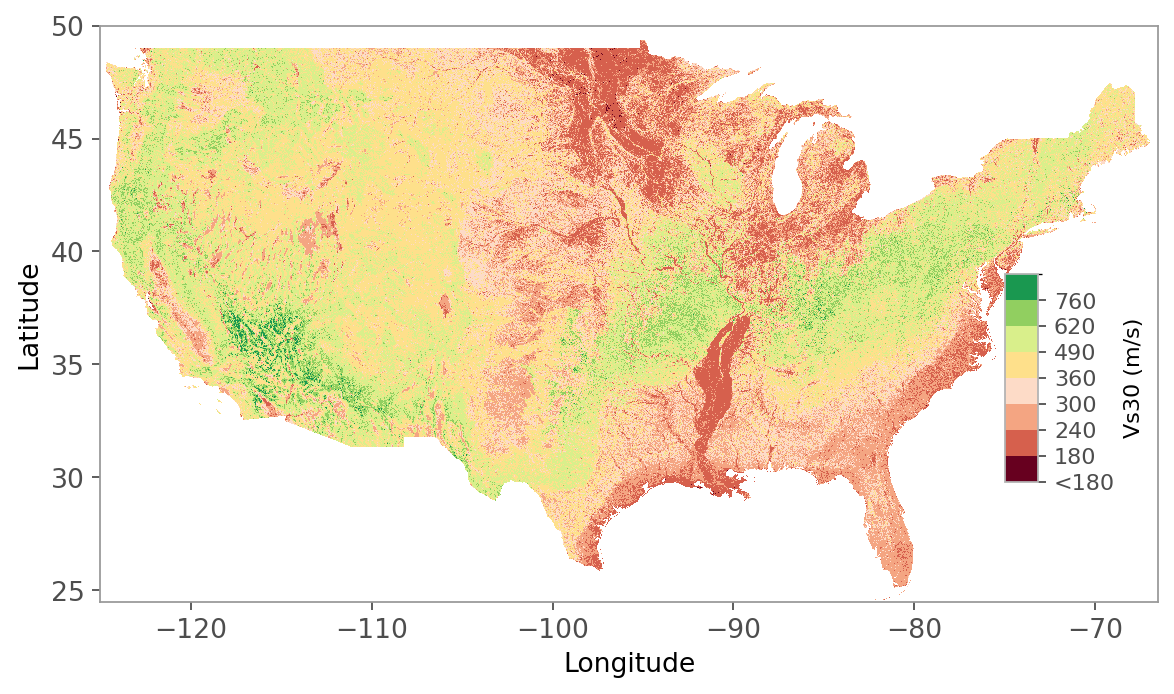

In [ ]:
from matplotlib.colors import ListedColormap, BoundaryNorm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

plt.rcParams.update({'font.size': 12})

vs30_boundaries = [0, 180, 240, 300, 360, 490, 620, 760, 1200]
vs30_colors = ['#67001f',
               '#d6604d',
               '#f4a582',
               '#fddbc7',
               '#fee08b',
               '#d9ef8b',
               '#91cf60',
               '#1a9850']

nehrp_cmap = ListedColormap(vs30_colors, name='nehrp')
nehrp_cmap.set_bad(color='white', alpha=0.0)
nehrp_norm = BoundaryNorm(vs30_boundaries, nehrp_cmap.N, clip=True)

def coord_edges(vals):
    vals = np.asarray(sorted(np.unique(vals)), dtype=float)
    if len(vals) == 1:
        return np.array([vals[0] - 0.5, vals[0] + 0.5])
    mids = 0.5 * (vals[:-1] + vals[1:])
    first = vals[0] - (mids[0] - vals[0])
    last = vals[-1] + (vals[-1] - mids[-1])
    return np.concatenate(([first], mids, [last]))

def build_vs30_grid(grid_df, value_col, lat_min=None, lat_max=None, lon_min=None, lon_max=None):
    plot_df = grid_df.copy()
    if lat_min is not None:
        plot_df = plot_df[plot_df[LAT_COL].between(lat_min, lat_max)]
    if lon_min is not None:
        plot_df = plot_df[plot_df[LON_COL].between(lon_min, lon_max)]

    lats = np.sort(plot_df[LAT_COL].unique())
    lons = np.sort(plot_df[LON_COL].unique())

    grid2d = (plot_df[[LAT_COL, LON_COL, value_col]]
              .pivot_table(index=LAT_COL, columns=LON_COL, values=value_col, aggfunc='mean')
              .reindex(index=lats, columns=lons))

    z = np.ma.masked_invalid(grid2d.to_numpy(dtype=float))
    return plot_df, lats, lons, z

def plot_vs30_conus_map(grid_df, vs30_col, ax):
    plot_df, lats_ax, lons_ax, vs30_grid = build_vs30_grid(
        grid_df,
        vs30_col,
        lat_min=CONUS['lat_min'],
        lat_max=CONUS['lat_max'],
        lon_min=CONUS['lon_min'],
        lon_max=CONUS['lon_max']
    )
    if plot_df.empty:
        raise ValueError("No CONUS grid points available for plotting.")

    lat_edges = coord_edges(lats_ax)
    lon_edges = coord_edges(lons_ax)

    im = ax.pcolormesh(
        lon_edges,
        lat_edges,
        vs30_grid,
        cmap=nehrp_cmap,
        norm=nehrp_norm,
        shading='flat',
        rasterized=True
    )

    # if '_get_conus_outline_info' in globals() and '_plot_geojson_outline' in globals():
    #     outline_info = _get_conus_outline_info()
    #     _plot_geojson_outline(ax, outline_info, color='0.35', lw=1.5, zorder=3)

    # ax.axvline(
    #     TECTONIC_BOUNDARY_LON,
    #     color='0.35',
    #     ls='--',
    #     lw=1.3,
    #     alpha=0.95,
    #     zorder=4
    # )

    ax.set_xlim(CONUS['lon_min'], CONUS['lon_max'])
    ax.set_ylim(CONUS['lat_min'], CONUS['lat_max'])
    ax.set_xticks(np.arange(-120, -69, 10))
    ax.set_yticks(np.arange(25, 51, 5))
    ax.set_xlabel('Longitude', fontsize=12)
    ax.set_ylabel('Latitude', fontsize=12)
    ax.set_facecolor('white')

    for spine in ax.spines.values():
        spine.set_color('0.6')
        spine.set_linewidth(0.8)
    ax.tick_params(colors='0.3', labelsize=12)

    return im

fig, ax = plt.subplots(figsize=(7.5, 4.5), dpi=160)
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

im = plot_vs30_conus_map(grid_feat, 'vs30_ml', ax)

cax = inset_axes(
    ax,
    width="3.2%",
    height="36%",
    loc='lower right',
    bbox_to_anchor=(0.0, 0.0, 1.0, 1.0),
    bbox_transform=ax.transAxes,
    borderpad=4.5
)

cbar = plt.colorbar(
    im,
    cax=cax,
    orientation='vertical',
    boundaries=vs30_boundaries,
    ticks=vs30_boundaries[:-1]
)
cbar.set_label('Vs30 (m/s)', fontsize=10)
cbar.outline.set_edgecolor('0.7')
cbar.ax.tick_params(labelsize=10, colors='0.3')
cbar.ax.set_yticklabels(['<180', '180', '240', '300', '360', '490', '620', '760'])

plt.tight_layout()
fig.savefig(os.path.join(CACHE_DIR, 'US_Vs30_ML.png'),
            dpi=300, bbox_inches='tight', facecolor='white')
fig.savefig(os.path.join(CACHE_DIR, 'US_Vs30_ML.pdf'), facecolor='white')
plt.show()
